
The notebook dones as follows from my larger codebase
1. load the saved binary spike tensors
2. compute observed W/M values from delayed binary spike transitions
3. build TDMI-matched discrete null distributions
4. convert the observed M values into subset-level Z-score summaries and save the tables and plot

Important constraint:
- `wimfo`'s discrete API only accepts four variables `(x1, x2, y1, y2)`.
- Because of that, direct discrete W/M is only defined on delayed 2-neuron transitions.
- For `k = 4, 8, 16, 32`, each sampled subset is summarised from sampled 2-neuron projections inside that subset.

following files should be in the same folder as the notebook to run
- `checkpoints/2class_local_hom.pt`
- `checkpoints/2class_fittedhet_lognorm.pt`
- `spk_tensors/2class_local_hom_spk_tensor.npy`
- `spk_tensors/2class_fittedhet_ln_spk_tensor.npy`
- `wimfo/`

uncertain items:
- The saved `.npy` arrays are the binary spike tensors from the correct recurrent-layer spike output (`spk_rec`).
- The checkpoints are included but this code uses the saved spike tensors directly.
- `W_M_calculator` is imported from the bundled `wimfo` repo/package and used through its discrete data and distribution paths.


- The null model below follows the NuMIT discrete recipe at the outer level: sample source-state probabilities from a Dirichlet distribution, choose a 2-bit logic gate family, match total information with bounded flip noise, then compare the observed quantity to that null.
- Because W/M requires a 2-past / 2-future PMF, the NuMIT-style discrete family is embedded into a 2-bit future representation rather than copied line-for-line from the original 2-source / 1-target PID code.

In [ ]:
import io
import sys
import math
import hashlib
import itertools
from pathlib import Path
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import torch

try:
    NB_DIR = Path(globals()['__vsc_ipynb_file__']).resolve().parent
except Exception:
    NB_DIR = Path(r"C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files")

# ignore this section its for my local file structure, this notebook should bypass this and still run if the files are in the same directory as this notebook
if (NB_DIR / 'checkpoints').exists() and (NB_DIR / 'spk_tensors').exists():
    ARTIFACT_DIR = NB_DIR
else:
    ARTIFACT_DIR = NB_DIR / 'Z - scoring issue'

CHECKPOINT_DIR = ARTIFACT_DIR / 'checkpoints'
SPK_TENSOR_DIR = ARTIFACT_DIR / 'spk_tensors'
OUTPUT_DIR = NB_DIR / 'discrete_estimator_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)


LOCAL_WIMFO_ROOT = ARTIFACT_DIR / 'wimfo'
FALLBACK_WIMFO_ROOT = NB_DIR.parent / 'wimfo'
for candidate in [LOCAL_WIMFO_ROOT, FALLBACK_WIMFO_ROOT]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

TARGETS = {
    '2class_local_hom': {
        'checkpoint': CHECKPOINT_DIR / '2class_local_hom.pt',
        'spike_tensor': SPK_TENSOR_DIR / '2class_local_hom_spk_tensor.npy',
    },
    '2class_fittedhet_ln': {
        'checkpoint': CHECKPOINT_DIR / '2class_fittedhet_lognorm.pt',
        'spike_tensor': SPK_TENSOR_DIR / '2class_fittedhet_ln_spk_tensor.npy',
    },
}

SUBSET_SIZES = [2, 4, 8, 16, 32]
SUBSET_SAMPLE_SIZE = 500
PAIR_SAMPLE_SIZE = 10
N_NULL = 20
SMOKE_SUBSET_SAMPLE_SIZE = 5
SMOKE_PAIR_SAMPLE_SIZE = 5
SMOKE_N_NULL = N_NULL
MAX_ATTEMPTS = 1200
OBS_DOWNSAMPLE_STRIDE = 4
TEMPORAL_DELAY_MS = 15.0

# The discrete solver is lifted from the external repo code from wimfo.
MIRROR_OPTIONS = {
    'steps': 200,
    'lr': 1e-1,
    'proj_max_iters': 500,
    'atol': 1e-4,
    'rtol': 1e-4,
    'window_size': 10,
}

try:
    from wimfo.W_M_Info import W_M_calculator
except Exception:
    import subprocess

    print('Installing wimfo...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wimfo'])
    from wimfo.W_M_Info import W_M_calculator

def _load_checkpoint(path):
    try:
        return torch.load(path, map_location='cpu')
    except TypeError:
        return torch.load(path, map_location='cpu', weights_only=False)
    except Exception:
        return torch.load(path, map_location='cpu', weights_only=False)


ckpt_probe = _load_checkpoint(CHECKPOINT_DIR / '2class_local_hom.pt')
RAW_STEP_MS = float(ckpt_probe['prms']['time_step']) * 1000.0
EFFECTIVE_STEP_MS = RAW_STEP_MS * OBS_DOWNSAMPLE_STRIDE
DELAY_STEPS = max(1, int(round(TEMPORAL_DELAY_MS / EFFECTIVE_STEP_MS)))
ACTUAL_DELAY_MS = DELAY_STEPS * EFFECTIVE_STEP_MS

print(f'Notebook dir         : {NB_DIR}')
print(f'Artifact dir         : {ARTIFACT_DIR}')
print(f'Checkpoint dir       : {CHECKPOINT_DIR}')
print(f'Spike tensor dir     : {SPK_TENSOR_DIR}')
print(f'Output dir           : {OUTPUT_DIR}')
print(f'Local wimfo dir      : {LOCAL_WIMFO_ROOT}')
print(f'Subset sizes         : {SUBSET_SIZES}')
print(f'Subset sample size   : {SUBSET_SAMPLE_SIZE}')
print(f'Pair sample size     : {PAIR_SAMPLE_SIZE}')
print(f'N_NULL               : {N_NULL}')
print(f'Smoke sample size    : {SMOKE_SUBSET_SAMPLE_SIZE}')
print(f'Smoke pair size      : {SMOKE_PAIR_SAMPLE_SIZE}')
print(f'Smoke N_NULL         : {SMOKE_N_NULL}')
print(f'Raw step             : {RAW_STEP_MS:.3f} ms')
print(f'Effective step       : {EFFECTIVE_STEP_MS:.3f} ms (stride={OBS_DOWNSAMPLE_STRIDE})')
print(f'Delay target         : {TEMPORAL_DELAY_MS:.1f} ms')
print(f'Delay steps          : {DELAY_STEPS}')
print(f'Actual delay         : {ACTUAL_DELAY_MS:.1f} ms')

Notebook dir         : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue
Artifact dir         : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue
Checkpoint dir       : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\checkpoints
Spike tensor dir     : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\spk_tensors
Output dir           : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\discrete_estimator_outputs
Local wimfo dir      : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\wimfo
Subset sizes         : [2, 4, 8, 16, 32]
Subset sample size   : 500
Pair sample size     : 10
N_NULL               : 20
Smoke sample size    : 5
Smoke pair size      : 5
Smoke N_NULL         : 20
Raw step             : 1.000 ms
Effective step       : 4.000 ms (stri

In [2]:
# Check the packaged files and load the saved binary spike tensors.
# The notebook scores these `.npy` tensors directly. The checkpoints are only here for provenance and timing metadata.
missing = []
for net_key, meta in TARGETS.items():
    ckpt_path = meta['checkpoint']
    spk_path = meta['spike_tensor']
    print(f'{net_key}: checkpoint={ckpt_path.exists()} | spike_tensor={spk_path.exists()}')
    if not ckpt_path.exists():
        missing.append(str(ckpt_path))
    if not spk_path.exists():
        missing.append(str(spk_path))

if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))


def load_spike_tensor(path):
    arr = np.load(path)
    if arr.ndim != 2:
        raise ValueError(f'Expected 2D [neurons x time] tensor, got {arr.shape} for {path.name}')
    arr = arr.astype(np.int8, copy=False)
    if not np.all((arr == 0) | (arr == 1)):
        raise ValueError(f'Spike tensor is not strictly binary for {path.name}')
    return arr


spike_tensors = {}
for net_key, meta in TARGETS.items():
    arr = load_spike_tensor(meta['spike_tensor'])
    spike_tensors[net_key] = arr
    print(f'{net_key:22s} shape={arr.shape} mean_rate={arr.mean():.4f}')

2class_local_hom: checkpoint=True | spike_tensor=True
2class_fittedhet_ln: checkpoint=True | spike_tensor=True
2class_local_hom       shape=(32, 128000) mean_rate=0.0755
2class_fittedhet_ln    shape=(32, 128000) mean_rate=0.0932


In [ ]:
# Observed discrete W/M and TDMI-matched null helpers.
# - `W_M_calculator` is external repo code from the bundled wimfo package.
# - The null distribution generation follows the NuMIT repo

def _stable_seed(*parts):
    token = '|'.join(map(str, parts)).encode('utf-8')
    return int(hashlib.sha256(token).hexdigest()[:8], 16)


def sample_random_subsets(n_neurons, subset_size, sample_size, seed):
    total_possible = math.comb(int(n_neurons), int(subset_size))
    target_size = min(int(sample_size), int(total_possible))

    if target_size == total_possible:
        all_subsets = itertools.combinations(range(int(n_neurons)), int(subset_size))
        return [tuple(idx) for idx in all_subsets], total_possible

    rng = np.random.default_rng(int(seed))
    sampled = set()
    while len(sampled) < target_size:
        subset = tuple(sorted(rng.choice(int(n_neurons), size=int(subset_size), replace=False).tolist()))
        sampled.add(subset)

    return sorted(sampled), total_possible


def sample_random_pairs(subset_idx, sample_size, seed):
    subset_idx = tuple(int(i) for i in subset_idx)
    total_possible = math.comb(len(subset_idx), 2)
    target_size = min(int(sample_size), int(total_possible))

    if target_size == total_possible:
        all_pairs = itertools.combinations(subset_idx, 2)
        return [tuple(pair) for pair in all_pairs], total_possible

    rng = np.random.default_rng(int(seed))
    sampled = set()
    while len(sampled) < target_size:
        pair_pos = sorted(rng.choice(len(subset_idx), size=2, replace=False).tolist())
        sampled.add((subset_idx[pair_pos[0]], subset_idx[pair_pos[1]]))

    return sorted(sampled), total_possible


def _downsample_binary_matrix(binary_matrix, stride=1):
    stride = max(int(stride), 1)
    return np.asarray(binary_matrix, dtype=np.int8)[:, ::stride]


def _encode_states(bits):
    weights = (1 << np.arange(bits.shape[0], dtype=np.int64))[:, None]
    return np.sum(bits.astype(np.int64) * weights, axis=0)


def _decode_state(idx, k):
    return np.array([(idx >> b) & 1 for b in range(int(k))], dtype=np.int8)


def _mi_from_joint_table(pxy, eps=1e-12):
    pxy = np.asarray(pxy, dtype=np.float64)
    pxy = np.clip(pxy, 0.0, None)
    total = pxy.sum()
    if total <= 0.0:
        return np.nan
    pxy = pxy / total
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    denom = px @ py
    mask = pxy > 0
    return float(np.sum(pxy[mask] * np.log2((pxy[mask] + eps) / (denom[mask] + eps))))


def calculate_discrete_mi(binary_matrix, delay_steps, stride=1):
    # Count discrete transitions P(X_t, X_t+dt) directly from binary spike states.
    x = _downsample_binary_matrix(binary_matrix, stride=stride)
    if x.ndim != 2:
        raise ValueError('binary_matrix must be [k x time].')
    k, t = x.shape
    if t <= int(delay_steps):
        raise ValueError('Not enough timepoints for requested delay after downsampling.')

    past = x[:, :-int(delay_steps)]
    fut = x[:, int(delay_steps):]

    x_state = _encode_states(past)
    y_state = _encode_states(fut)
    n_states = 2 ** int(k)

    counts = np.zeros((n_states, n_states), dtype=np.float64)
    np.add.at(counts, (x_state, y_state), 1.0)
    pxy = counts / counts.sum()
    mi_bits = _mi_from_joint_table(pxy)
    return float(mi_bits), pxy


NULL_GATES = ('XOR', 'XOR2', 'XOR3', 'OR', 'OR2', 'OR3', 'OR4')
GATE_ZERO_STATES = {
    'XOR': {(0, 0), (1, 1)},
    'XOR2': {(0, 0), (0, 1)},
    'XOR3': {(0, 0), (1, 0)},
    'OR': {(0, 0)},
    'OR2': {(0, 1)},
    'OR3': {(1, 0)},
    'OR4': {(1, 1)},
}


def sample_dirichlet_nulls(rng, n_states):
    # NuMIT's discrete null samples source-state probabilities from a Dirichlet family.
    if int(n_states) != 4:
        raise ValueError('The NuMIT-style discrete null is defined for 2 source bits.')
    alpha_scale = float(rng.uniform(0.1, 3.0))
    alpha = np.full(int(n_states), alpha_scale, dtype=np.float64)
    return rng.dirichlet(alpha), alpha_scale


def _logic_proxy(bits, gate):
    state = (int(bits[0]), int(bits[1]))
    return 0 if state in GATE_ZERO_STATES[gate] else 1


def _build_joint_from_px_logic(px, p_eps, gate, k=2):
    if int(k) != 2:
        raise ValueError('Current discrete null is constrained to k=2.')

    n_states = 2 ** int(k)
    pxy = np.zeros((n_states, n_states), dtype=np.float64)

    for x_idx in range(n_states):
        x_bits = _decode_state(x_idx, k)
        # The first future bit follows the NuMIT gate family.
        # The second bit is a simple source copy so the future stays 2-dimensional for W/M.
        y_det = np.array([_logic_proxy(x_bits, gate), x_bits[0]], dtype=np.int8)

        for y_idx in range(n_states):
            y_bits = _decode_state(y_idx, k)
            hamming = np.count_nonzero(y_bits != y_det)
            p_cond = (float(p_eps) ** hamming) * ((1.0 - float(p_eps)) ** (int(k) - hamming))
            pxy[x_idx, y_idx] = float(px[x_idx]) * p_cond

    pxy = pxy / pxy.sum()

    pmf4 = np.zeros((2, 2, 2, 2), dtype=np.float64)
    for x_idx in range(n_states):
        xb = _decode_state(x_idx, k)
        for y_idx in range(n_states):
            yb = _decode_state(y_idx, k)
            pmf4[xb[0], xb[1], yb[0], yb[1]] = pxy[x_idx, y_idx]

    return pxy, pmf4


def _numit_discrete_from_mi(tdmi_target_bits, rng, k=2, tol_bits=0.03):
    if int(k) != 2:
        raise ValueError('Discrete null fitting is constrained to k=2.')

    px, alpha_scale = sample_dirichlet_nulls(rng, n_states=2 ** int(k))
    gate = str(rng.choice(NULL_GATES))

    # Skip draws that cannot reach the requested TDMI even at zero noise.
    pxy_zero, _ = _build_joint_from_px_logic(px, p_eps=0.0, gate=gate, k=k)
    max_tdmi_bits = _mi_from_joint_table(pxy_zero)
    if (not np.isfinite(max_tdmi_bits)) or (float(max_tdmi_bits) + float(tol_bits) < float(tdmi_target_bits)):
        return None, None, True, float(max_tdmi_bits), np.nan, gate, alpha_scale

    def f(p_eps):
        pxy, _ = _build_joint_from_px_logic(px, p_eps=float(p_eps), gate=gate, k=k)
        return _mi_from_joint_table(pxy) - float(tdmi_target_bits)

    grid = np.linspace(0.0, 0.499, 100, dtype=np.float64)
    vals = np.asarray([f(p) for p in grid], dtype=np.float64)
    finite = np.isfinite(vals)
    if not np.any(finite):
        return None, None, True, np.nan, np.nan, gate, alpha_scale

    grid = grid[finite]
    vals = vals[finite]

    nearest = int(np.argmin(np.abs(vals)))
    if abs(vals[nearest]) <= float(tol_bits):
        p_star = float(grid[nearest])
    else:
        p_star = None
        for idx in range(len(grid) - 1):
            left = float(vals[idx])
            right = float(vals[idx + 1])
            if left == 0.0:
                p_star = float(grid[idx])
                break
            if left * right > 0.0:
                continue
            try:
                sol = root_scalar(
                    f,
                    bracket=[float(grid[idx]), float(grid[idx + 1])],
                    method='brentq',
                    xtol=1e-6,
                    rtol=1e-6,
                    maxiter=100,
                )
            except Exception:
                sol = None
            if sol is not None and sol.converged and np.isfinite(sol.root):
                p_star = float(sol.root)
                break

    if p_star is None:
        return None, None, True, np.nan, np.nan, gate, alpha_scale

    pxy, pmf4 = _build_joint_from_px_logic(px, p_eps=p_star, gate=gate, k=k)
    mi_check = _mi_from_joint_table(pxy)
    if not np.isfinite(mi_check):
        return None, None, True, np.nan, np.nan, gate, alpha_scale

    return pxy, pmf4, False, float(mi_check), float(p_star), gate, alpha_scale


def _wm_from_discrete_pmf(joint_pmf_4d, alphabet_size=2):
    # External repo call: discrete wimfo path on a 2x2x2x2 PMF.
    with io.StringIO() as buf, redirect_stdout(buf):
        w_bits, m_bits = W_M_calculator(
            joint_pmf_4d,
            option='distr',
            type='discrete',
            alphabet_size=int(alphabet_size),
            unit='bits',
            verbose=False,
            optimiser='Mirror',
            options=MIRROR_OPTIONS,
        )
    return float(w_bits), float(m_bits)


def compute_observed_wm_discrete(binary_matrix, delay_steps, stride=1):
    # Observed discrete W/M is computed directly from delayed binary spike transitions.
    binary_matrix = _downsample_binary_matrix(binary_matrix, stride=stride)
    if binary_matrix.shape[0] != 2:
        raise ValueError('Fully discrete wimfo scoring expects exactly 2 neurons per projection.')
    if binary_matrix.shape[1] <= int(delay_steps):
        raise ValueError('Not enough samples after downsampling for the requested delay.')

    x1 = binary_matrix[0, :-int(delay_steps)].astype(np.int64)
    x2 = binary_matrix[1, :-int(delay_steps)].astype(np.int64)
    y1 = binary_matrix[0, int(delay_steps):].astype(np.int64)
    y2 = binary_matrix[1, int(delay_steps):].astype(np.int64)
    data4 = np.vstack([x1, x2, y1, y2])

    with io.StringIO() as buf, redirect_stdout(buf):
        w_bits, m_bits = W_M_calculator(
            data4,
            option='data',
            type='discrete',
            alphabet_size=2,
            unit='bits',
            verbose=False,
            optimiser='Mirror',
            options=MIRROR_OPTIONS,
        )

    tdmi_bits, _ = calculate_discrete_mi(binary_matrix, delay_steps=delay_steps, stride=1)
    return float(w_bits), float(m_bits), float(tdmi_bits)


def build_numit_discrete_null_distribution(nvar, tdmi_target_bits, n_null=20, seed=12345, max_attempts=1200):
    # Keep the same outer NuMIT logic as the handoff notebook: match TDMI first, then score M against the null.
    if int(nvar) != 2:
        raise ValueError('The discrete null generator is constrained to nvar=2.')

    rng = np.random.default_rng(int(seed))
    null_m = []
    null_w = []
    model_mi_vals = []
    model_p_eps = []
    model_gate = []
    model_alpha = []

    attempts = 0
    while len(null_m) < int(n_null) and attempts < int(max_attempts):
        attempts += 1

        pxy, pmf4, failed, mi_model, p_eps, gate, alpha_scale = _numit_discrete_from_mi(
            tdmi_target_bits=tdmi_target_bits,
            rng=rng,
            k=int(nvar),
            tol_bits=0.03,
        )
        if failed:
            continue

        try:
            w_bits, m_bits = _wm_from_discrete_pmf(pmf4, alphabet_size=2)
        except Exception:
            continue

        if not (np.isfinite(w_bits) and np.isfinite(m_bits)):
            continue

        null_w.append(float(w_bits))
        null_m.append(float(m_bits))
        model_mi_vals.append(float(mi_model))
        model_p_eps.append(float(p_eps))
        model_gate.append(str(gate))
        model_alpha.append(float(alpha_scale))

    return {
        'null_M_values': null_m,
        'null_W_values': null_w,
        'model_mi_bits': model_mi_vals,
        'model_p_eps': model_p_eps,
        'model_gate': model_gate,
        'model_alpha': model_alpha,
        'n_null_valid': int(len(null_m)),
        'n_attempts': int(attempts),
    }


def score_observed_vs_null_m(observed_m, null_m_values):
    vals = np.asarray(null_m_values, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {
            'null_mean': np.nan,
            'null_std': np.nan,
            'z': np.nan,
            'p_upper': np.nan,
            'p_lower': np.nan,
            'p_two_sided': np.nan,
        }

    mu = float(vals.mean())
    sd = float(vals.std(ddof=1)) if vals.size > 1 else np.nan
    z = float((float(observed_m) - mu) / sd) if (np.isfinite(sd) and sd > 1e-12) else np.nan

    ge = np.sum(vals >= float(observed_m))
    le = np.sum(vals <= float(observed_m))
    p_upper = float((1.0 + ge) / (vals.size + 1.0))
    p_lower = float((1.0 + le) / (vals.size + 1.0))
    p_two = float(min(1.0, 2.0 * min(p_upper, p_lower)))

    return {
        'null_mean': mu,
        'null_std': sd,
        'z': z,
        'p_upper': p_upper,
        'p_lower': p_lower,
        'p_two_sided': p_two,
    }

In [ ]:
# Sample subsets, score pairwise discrete projections, and summarise by subset.
# For k > 2 the direct discrete estimator is not available, so each subset is reduced
# to a bounded set of 2-neuron projections and then aggregated at the subset level.
# I am not certain this is the correct way to do the discrete estimation so please advise if an alternate route is needed

def _save_subset_boxplot(subset_df, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, net_key in zip(axes, ['2class_local_hom', '2class_fittedhet_ln']):
        sub = subset_df[subset_df['network'] == net_key].sort_values(['subset_size', 'subset_draw'])
        box_data = []
        tick_labels = []
        for subset_size in SUBSET_SIZES:
            vals = sub.loc[sub['subset_size'] == subset_size, 'subset_pair_z_mean'].dropna().to_numpy()
            if vals.size == 0:
                continue
            box_data.append(vals)
            tick_labels.append(str(int(subset_size)))

        if box_data:
            ax.boxplot(box_data, tick_labels=tick_labels, showfliers=False)
        ax.axhline(0.0, color='gray', linewidth=1, linestyle='--')
        ax.set_title(net_key + ' discrete pair summaries')
        ax.set_xlabel('subset size')
        ax.set_ylabel('subset mean pair Z score')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plot_path = OUTPUT_DIR / f'discrete_estimator_{label}_zscores.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    return plot_path


def run_discrete_projection_scan(subset_sample_size, pair_sample_size, n_null, label):
    pair_records = []
    subset_records = []

    for net_key, spk in spike_tensors.items():
        n_neurons = int(spk.shape[0])
        print(f'\n{label} :: {net_key}')

        for subset_size in SUBSET_SIZES:
            sampled_subsets, total_possible_subsets = sample_random_subsets(
                n_neurons=n_neurons,
                subset_size=int(subset_size),
                sample_size=int(subset_sample_size),
                seed=_stable_seed(net_key, label, 'subset_sampling', subset_size),
            )

            subset_z_means = []
            for subset_draw, subset_idx in enumerate(sampled_subsets, start=1):
                sampled_pairs, total_possible_pairs = sample_random_pairs(
                    subset_idx=subset_idx,
                    sample_size=int(pair_sample_size),
                    seed=_stable_seed(net_key, label, 'pair_sampling', subset_size, subset_draw),
                )

                subset_pair_rows = []
                for pair_draw, (pair_i, pair_j) in enumerate(sampled_pairs, start=1):
                    try:
                        obs_w, obs_m, obs_tdmi_counts = compute_observed_wm_discrete(
                            spk[[int(pair_i), int(pair_j)], :],
                            delay_steps=DELAY_STEPS,
                            stride=OBS_DOWNSAMPLE_STRIDE,
                        )
                        observed_tdmi = float(obs_w + obs_m)
                        null_dist = build_numit_discrete_null_distribution(
                            nvar=2,
                            tdmi_target_bits=observed_tdmi,
                            n_null=int(n_null),
                            seed=_stable_seed(net_key, label, subset_size, subset_draw, pair_i, pair_j),
                            max_attempts=MAX_ATTEMPTS,
                        )
                        score = score_observed_vs_null_m(obs_m, null_dist['null_M_values'])

                        model_mi = np.asarray(null_dist['model_mi_bits'], dtype=np.float64)
                        model_p_eps = np.asarray(null_dist['model_p_eps'], dtype=np.float64)
                        model_alpha = np.asarray(null_dist['model_alpha'], dtype=np.float64)
                        status = 'ok'
                    except Exception as exc:
                        obs_w = np.nan
                        obs_m = np.nan
                        obs_tdmi_counts = np.nan
                        observed_tdmi = np.nan
                        null_dist = {
                            'n_null_valid': 0,
                            'n_attempts': 0,
                            'model_gate': [],
                        }
                        score = score_observed_vs_null_m(np.nan, [])
                        model_mi = np.asarray([], dtype=np.float64)
                        model_p_eps = np.asarray([], dtype=np.float64)
                        model_alpha = np.asarray([], dtype=np.float64)
                        status = f'error: {exc}'

                    pair_record = {
                        'run_label': label,
                        'network': net_key,
                        'subset_size': int(subset_size),
                        'subset_draw': int(subset_draw),
                        'subset_indices': ','.join(map(str, subset_idx)),
                        'total_possible_subsets': int(total_possible_subsets),
                        'sampled_pairs_in_subset': int(len(sampled_pairs)),
                        'total_possible_pairs_in_subset': int(total_possible_pairs),
                        'pair_draw': int(pair_draw),
                        'pair_i': int(pair_i),
                        'pair_j': int(pair_j),
                        'delay_steps': int(DELAY_STEPS),
                        'delay_ms': float(ACTUAL_DELAY_MS),
                        'observed_W_bits': float(obs_w) if np.isfinite(obs_w) else np.nan,
                        'observed_M_bits': float(obs_m) if np.isfinite(obs_m) else np.nan,
                        'observed_TDMI_bits': float(observed_tdmi) if np.isfinite(observed_tdmi) else np.nan,
                        'observed_TDMI_counts_bits': float(obs_tdmi_counts) if np.isfinite(obs_tdmi_counts) else np.nan,
                        'null_M_mean': score['null_mean'],
                        'null_M_std': score['null_std'],
                        'M_z_tdmi_null': score['z'],
                        'M_p_upper_tdmi_null': score['p_upper'],
                        'M_p_lower_tdmi_null': score['p_lower'],
                        'M_p_two_sided_tdmi_null': score['p_two_sided'],
                        'n_null_valid': int(null_dist['n_null_valid']),
                        'n_attempts': int(null_dist['n_attempts']),
                        'null_model_mi_mean': float(np.nanmean(model_mi)) if model_mi.size else np.nan,
                        'null_model_p_eps_mean': float(np.nanmean(model_p_eps)) if model_p_eps.size else np.nan,
                        'null_model_alpha_mean': float(np.nanmean(model_alpha)) if model_alpha.size else np.nan,
                        'null_gate_modes': ','.join(sorted(set(null_dist['model_gate']))),
                        'status': status,
                    }
                    pair_records.append(pair_record)
                    subset_pair_rows.append(pair_record)

                subset_pair_df = pd.DataFrame.from_records(subset_pair_rows)
                subset_z = subset_pair_df['M_z_tdmi_null'].dropna().to_numpy() if not subset_pair_df.empty else np.array([], dtype=np.float64)
                subset_upper = subset_pair_df['M_p_upper_tdmi_null'].dropna().to_numpy() if not subset_pair_df.empty else np.array([], dtype=np.float64)
                subset_lower = subset_pair_df['M_p_lower_tdmi_null'].dropna().to_numpy() if not subset_pair_df.empty else np.array([], dtype=np.float64)

                subset_record = {
                    'run_label': label,
                    'network': net_key,
                    'subset_size': int(subset_size),
                    'subset_draw': int(subset_draw),
                    'subset_indices': ','.join(map(str, subset_idx)),
                    'total_possible_subsets': int(total_possible_subsets),
                    'sampled_pairs': int(len(sampled_pairs)),
                    'total_possible_pairs': int(total_possible_pairs),
                    'subset_pair_z_mean': float(np.nanmean(subset_z)) if subset_z.size else np.nan,
                    'subset_pair_z_median': float(np.nanmedian(subset_z)) if subset_z.size else np.nan,
                    'subset_pair_z_max': float(np.nanmax(subset_z)) if subset_z.size else np.nan,
                    'subset_pair_z_min': float(np.nanmin(subset_z)) if subset_z.size else np.nan,
                    'subset_pair_p_upper_mean': float(np.nanmean(subset_upper)) if subset_upper.size else np.nan,
                    'subset_pair_p_lower_mean': float(np.nanmean(subset_lower)) if subset_lower.size else np.nan,
                    'subset_positive_frac': float(np.mean(subset_z > 0.0)) if subset_z.size else np.nan,
                }
                subset_records.append(subset_record)
                subset_z_means.append(subset_record['subset_pair_z_mean'])

            finite_subset_z = [value for value in subset_z_means if np.isfinite(value)]
            mean_subset_z = float(np.mean(finite_subset_z)) if finite_subset_z else np.nan
            print(
                f'  k={subset_size:2d} | sampled {len(sampled_subsets):3d} / {total_possible_subsets} subsets | '
                f'mean subset Z={mean_subset_z:8.3f}'
            )

    pair_df = pd.DataFrame.from_records(pair_records)
    subset_df = pd.DataFrame.from_records(subset_records)

    if not pair_df.empty:
        pair_df = pair_df.sort_values(['network', 'subset_size', 'subset_draw', 'pair_draw']).reset_index(drop=True)
    if not subset_df.empty:
        subset_df = subset_df.sort_values(['network', 'subset_size', 'subset_draw']).reset_index(drop=True)

    overall_df = (
        subset_df.groupby(['network', 'subset_size'], as_index=False)
        .agg(
            sampled_subsets=('subset_draw', 'count'),
            sampled_pairs_mean=('sampled_pairs', 'mean'),
            subset_pair_z_mean=('subset_pair_z_mean', 'mean'),
            subset_pair_z_median=('subset_pair_z_mean', 'median'),
            subset_pair_z_max=('subset_pair_z_max', 'max'),
            subset_pair_z_min=('subset_pair_z_min', 'min'),
            subset_positive_frac=('subset_positive_frac', 'mean'),
            subset_pair_p_upper_mean=('subset_pair_p_upper_mean', 'mean'),
            subset_pair_p_lower_mean=('subset_pair_p_lower_mean', 'mean'),
        )
        .sort_values(['network', 'subset_size'])
        .reset_index(drop=True)
    )

    pair_csv = OUTPUT_DIR / f'discrete_estimator_pairs_{label}.csv'
    subset_csv = OUTPUT_DIR / f'discrete_estimator_subset_summary_{label}.csv'
    overall_csv = OUTPUT_DIR / f'discrete_estimator_overall_{label}.csv'

    pair_df.to_csv(pair_csv, index=False)
    subset_df.to_csv(subset_csv, index=False)
    overall_df.to_csv(overall_csv, index=False)
    plot_path = _save_subset_boxplot(subset_df, label)

    print(f'\nSaved pair-level CSV   : {pair_csv}')
    print(f'Saved subset-level CSV : {subset_csv}')
    print(f'Saved overall CSV      : {overall_csv}')
    print(f'Saved plot             : {plot_path}')

    return pair_df, subset_df, overall_df, plot_path


smoke_n5 :: 2class_local_hom
  k= 2 | sampled   5 / 496 subsets | mean subset Z=  -1.289
  k= 4 | sampled   5 / 35960 subsets | mean subset Z=  -1.128
  k= 8 | sampled   5 / 10518300 subsets | mean subset Z=  -0.918
  k=16 | sampled   5 / 601080390 subsets | mean subset Z=  -1.157
  k=32 | sampled   1 / 1 subsets | mean subset Z=  -0.695

smoke_n5 :: 2class_fittedhet_ln
  k= 2 | sampled   5 / 496 subsets | mean subset Z=  -1.701
  k= 4 | sampled   5 / 35960 subsets | mean subset Z=  -1.231
  k= 8 | sampled   5 / 10518300 subsets | mean subset Z=  -1.323
  k=16 | sampled   5 / 601080390 subsets | mean subset Z=  -1.091
  k=32 | sampled   1 / 1 subsets | mean subset Z=  -0.670


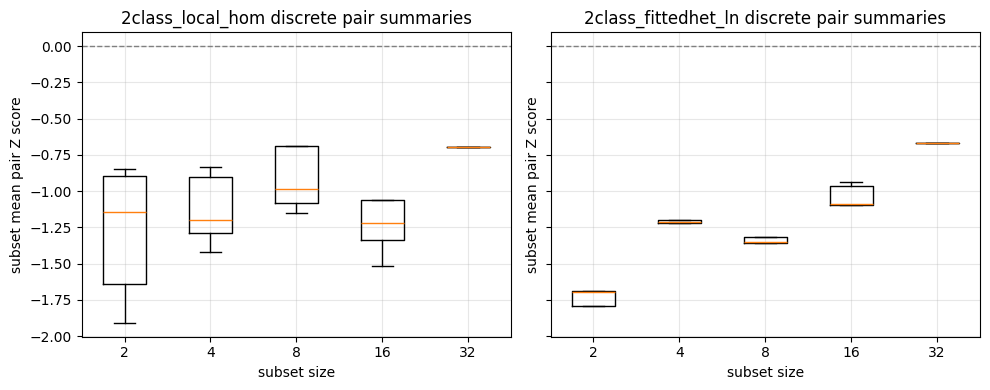


Saved pair-level CSV   : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\discrete_estimator_outputs\discrete_estimator_pairs_smoke_n5.csv
Saved subset-level CSV : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\discrete_estimator_outputs\discrete_estimator_subset_summary_smoke_n5.csv
Saved overall CSV      : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\discrete_estimator_outputs\discrete_estimator_overall_smoke_n5.csv
Saved plot             : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Z - scoring issue\discrete_estimator_outputs\discrete_estimator_smoke_n5_zscores.png

Smoke run complete.


,network,subset_size,sampled_subsets,sampled_pairs_mean,subset_pair_z_mean,subset_pair_z_median,subset_pair_z_max,subset_pair_z_min,subset_positive_frac,subset_pair_p_upper_mean,subset_pair_p_lower_mean
0,2class_fittedhet_ln,2,5,1.0,-1.701476,-1.695513,-0.922905,-2.407045,0.00,0.952381,0.095238
1,2class_fittedhet_ln,4,5,5.0,-1.230586,-1.211939,-0.074847,-2.716457,0.00,0.868571,0.180952
2,2class_fittedhet_ln,8,5,5.0,-1.323183,-1.351282,-0.470039,-1.887995,0.00,0.914286,0.133333
3,2class_fittedhet_ln,16,5,5.0,-1.090972,-1.087146,0.648160,-1.926985,0.04,0.868571,0.179048
4,2class_fittedhet_ln,32,1,5.0,-0.669836,-0.669836,0.565483,-1.405602,0.20,0.695238,0.352381
5,2class_local_hom,2,5,1.0,-1.288972,-1.145204,-0.849934,-1.909271,0.00,0.876190,0.171429
6,2class_local_hom,4,5,5.0,-1.128325,-1.200321,0.209397,-2.418246,0.08,0.841905,0.207619
7,2class_local_hom,8,5,5.0,-0.917875,-0.985258,0.258649,-2.136332,0.12,0.801905,0.245714
8,2class_local_hom,16,5,5.0,-1.156804,-1.218996,0.866110,-2.368666,0.04,0.847619,0.200000
9,2class_local_hom,32,1,5.0,-0.695313,-0.695313,1.749247,-1.806036,0.20,0.714286,0.333333


,run_label,network,subset_size,subset_draw,subset_indices,total_possible_subsets,sampled_pairs,total_possible_pairs,subset_pair_z_mean,subset_pair_z_median,subset_pair_z_max,subset_pair_z_min,subset_pair_p_upper_mean,subset_pair_p_lower_mean,subset_positive_frac
0,smoke_n5,2class_fittedhet_ln,2,1,"9,19",496,1,1,-0.922905,-0.922905,-0.922905,-0.922905,0.809524,0.238095,0.0
1,smoke_n5,2class_fittedhet_ln,2,2,"11,16",496,1,1,-1.688979,-1.688979,-1.688979,-1.688979,1.000000,0.047619,0.0
2,smoke_n5,2class_fittedhet_ln,2,3,"13,30",496,1,1,-1.695513,-1.695513,-1.695513,-1.695513,0.952381,0.095238,0.0
3,smoke_n5,2class_fittedhet_ln,2,4,"19,26",496,1,1,-1.792938,-1.792938,-1.792938,-1.792938,1.000000,0.047619,0.0
4,smoke_n5,2class_fittedhet_ln,2,5,"23,25",496,1,1,-2.407045,-2.407045,-2.407045,-2.407045,1.000000,0.047619,0.0
5,smoke_n5,2class_fittedhet_ln,4,1,"1,6,19,26",35960,5,6,-1.219437,-1.273362,-0.617974,-1.756607,0.866667,0.180952,0.0
6,smoke_n5,2class_fittedhet_ln,4,2,"1,7,17,30",35960,5,6,-1.365397,-1.275816,-0.627572,-2.716457,0.847619,0.209524,0.0
7,smoke_n5,2class_fittedhet_ln,4,3,"2,4,5,12",35960,5,6,-1.211939,-1.314171,-0.644354,-1.581790,0.942857,0.104762,0.0
8,smoke_n5,2class_fittedhet_ln,4,4,"7,9,15,27",35960,5,6,-1.196461,-1.288155,-0.074847,-2.158226,0.819048,0.228571,0.0
9,smoke_n5,2class_fittedhet_ln,4,5,"16,20,24,25",35960,5,6,-1.159698,-1.097103,-0.303408,-2.019301,0.866667,0.180952,0.0


In [5]:
# Smoke run: same subset sizes as the full pass, but only 5 sampled subsets per size.
smoke_pair_df, smoke_subset_df, smoke_overall_df, smoke_plot_path = run_discrete_projection_scan(
    subset_sample_size=SMOKE_SUBSET_SAMPLE_SIZE,
    pair_sample_size=SMOKE_PAIR_SAMPLE_SIZE,
    n_null=SMOKE_N_NULL,
    label='smoke_n5',
)

print('\nSmoke run complete.')
display(smoke_overall_df)
display(smoke_subset_df.head(10))

In [ ]:
# Full reun implementer
RUN_FULL = False

if RUN_FULL:
    full_pair_df, full_subset_df, full_overall_df, full_plot_path = run_discrete_projection_scan(
        subset_sample_size=SUBSET_SAMPLE_SIZE,
        pair_sample_size=PAIR_SAMPLE_SIZE,
        n_null=N_NULL,
        label='full_n500',
    )
    print('\nFull run complete.')
    display(full_overall_df)
else:
    print(
        'Set RUN_FULL = True to execute the full fixed-N discrete scan '
        '(500 sampled subsets per size and up to 10 pair projections per subset).'
    )

Set RUN_FULL = True to execute the full fixed-N discrete scan (500 sampled subsets per size and up to 10 pair projections per subset).
